In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

with open("../../data/equipment_failure/meta.json") as f:
    meta = json.load(f)

useful_sensors = meta["useful_sensors"]
top_sensors = meta["top_sensors"]
CLIP_RUL = meta["clip_rul"]

col_names = ["unit_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
train_df = pd.read_csv("../../data/equipment_failure/CMaps/train_FD001.txt",
                        sep=r"\s+", header=None, names=col_names, engine="python")
test_df = pd.read_csv("../../data/equipment_failure/CMaps/test_FD001.txt",
                       sep=r"\s+", header=None, names=col_names, engine="python")
rul_df = pd.read_csv("../../data/equipment_failure/CMaps/RUL_FD001.txt",
                      header=None, names=["RUL"])

for df in [train_df, test_df]:
    df.dropna(axis=1, inplace=True)
    df["unit_id"] = df["unit_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)

max_cycles = train_df.groupby("unit_id")["cycle"].max().reset_index()
max_cycles.columns = ["unit_id", "max_cycle"]
train_df = train_df.merge(max_cycles, on="unit_id")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df["RUL_clipped"] = train_df["RUL"].clip(upper=CLIP_RUL)
train_df = train_df.drop(columns=["max_cycle"])

print("Data loaded successfully")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Useful sensors: {useful_sensors}")

Data loaded successfully
Train: (20631, 28) | Test: (13096, 26)
Useful sensors: ['s9', 's14', 's4', 's3', 's17', 's7', 's12', 's2', 's11', 's20', 's21', 's13', 's8', 's15']


ROLLING WINDOW FEATURES

Rolling statistics capture how sensors are CHANGING over time.
This is critical — degradation is a process, not a snapshot.

Adding rolling features for top 6 sensors with window sizes: [5, 10, 20, 30]
Rolling features created: 96
Example features: ['s11_roll_mean_5', 's11_roll_std_5', 's11_roll_min_5', 's11_roll_max_5', 's11_roll_mean_10', 's11_roll_std_10']



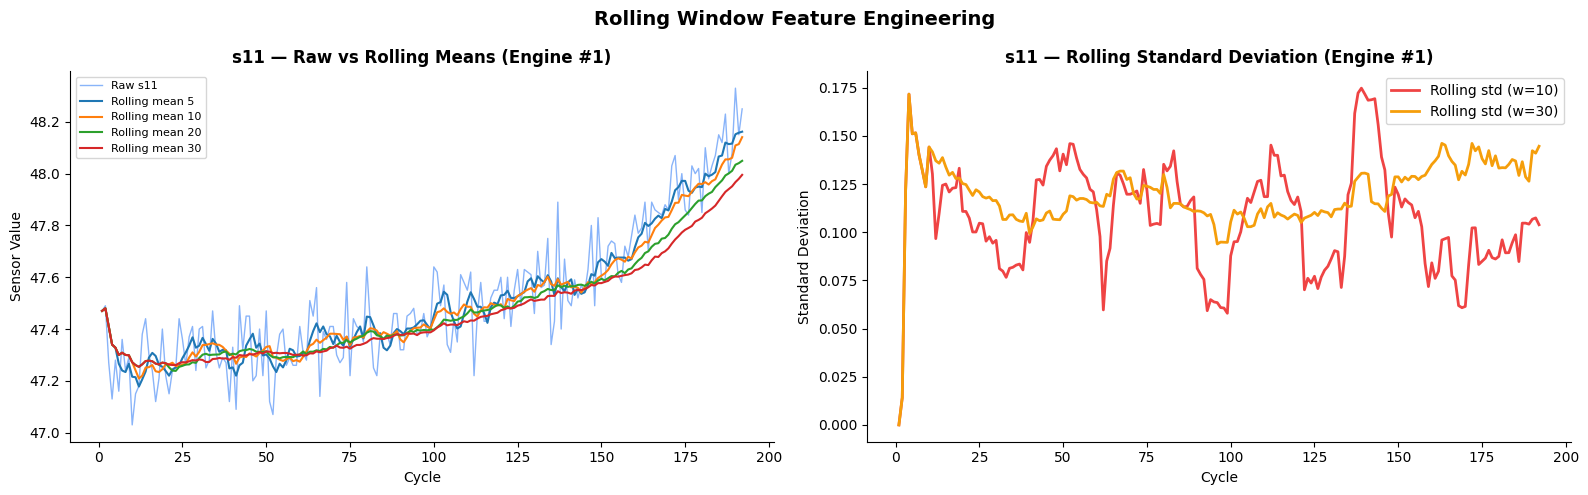

In [2]:
#  Rolling Window Features
print("ROLLING WINDOW FEATURES")
print()
print("Rolling statistics capture how sensors are CHANGING over time.")
print("This is critical — degradation is a process, not a snapshot.")
print()

WINDOW_SIZES = [5, 10, 20, 30]

def add_rolling_features(df, sensors, windows):
    df = df.sort_values(["unit_id", "cycle"]).copy()
    for sensor in sensors:
        for w in windows:
            grp = df.groupby("unit_id")[sensor]
            df[f"{sensor}_roll_mean_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
            df[f"{sensor}_roll_std_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            df[f"{sensor}_roll_min_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).min())
            df[f"{sensor}_roll_max_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).max())
    return df

print("Adding rolling features for top 6 sensors with window sizes:", WINDOW_SIZES)
top6 = top_sensors[:6]
train_df = add_rolling_features(train_df, top6, WINDOW_SIZES)
test_df = add_rolling_features(test_df, top6, WINDOW_SIZES)

rolling_cols = [c for c in train_df.columns if "roll_" in c]
print(f"Rolling features created: {len(rolling_cols)}")
print(f"Example features: {rolling_cols[:6]}")
print()

sample_eng = train_df[train_df["unit_id"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sample_eng["cycle"], sample_eng["s11"], color="#3b82f6", linewidth=1, alpha=0.6, label="Raw s11")
for w in WINDOW_SIZES:
    axes[0].plot(sample_eng["cycle"], sample_eng[f"s11_roll_mean_{w}"], linewidth=1.5, label=f"Rolling mean {w}")
axes[0].set_title("s11 — Raw vs Rolling Means (Engine #1)", fontweight="bold")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Sensor Value")
axes[0].legend(fontsize=8)

axes[1].plot(sample_eng["cycle"], sample_eng[f"s11_roll_std_10"], color="#ef4444", linewidth=2, label="Rolling std (w=10)")
axes[1].plot(sample_eng["cycle"], sample_eng[f"s11_roll_std_30"], color="#f59e0b", linewidth=2, label="Rolling std (w=30)")
axes[1].set_title("s11 — Rolling Standard Deviation (Engine #1)", fontweight="bold")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("Standard Deviation")
axes[1].legend()

plt.suptitle("Rolling Window Feature Engineering", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/rolling_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
#  Lag Features and Rate of Change
print("LAG FEATURES AND RATE OF CHANGE")
print()

def add_lag_features(df, sensors, lags=[1, 2, 5]):
    df = df.sort_values(["unit_id", "cycle"]).copy()
    for sensor in sensors:
        for lag in lags:
            df[f"{sensor}_lag_{lag}"] = df.groupby("unit_id")[sensor].shift(lag).fillna(method="bfill")
            df[f"{sensor}_diff_{lag}"] = df[sensor] - df[f"{sensor}_lag_{lag}"]
    return df

train_df = add_lag_features(train_df, top6)
test_df = add_lag_features(test_df, top6)

lag_cols = [c for c in train_df.columns if "lag_" in c or "diff_" in c]
print(f"Lag features created: {len(lag_cols)}")

print()
print("Rate of change analysis (mean diff per cycle near failure):")
for sensor in top_sensors[:4]:
    near_failure = train_df[train_df["RUL"] <= 30]
    healthy = train_df[train_df["RUL"] >= 100]
    near_diff = near_failure[f"{sensor}_diff_1"].mean() if f"{sensor}_diff_1" in train_df.columns else 0
    healthy_diff = healthy[f"{sensor}_diff_1"].mean() if f"{sensor}_diff_1" in train_df.columns else 0
    print(f"  {sensor}: near failure diff={near_diff:.4f}  healthy diff={healthy_diff:.4f}")

LAG FEATURES AND RATE OF CHANGE

Lag features created: 36

Rate of change analysis (mean diff per cycle near failure):
  s11: near failure diff=0.0133  healthy diff=0.0011
  s4: near failure diff=0.4590  healthy diff=0.0404
  s12: near failure diff=-0.0344  healthy diff=-0.0031
  s7: near failure diff=-0.0406  healthy diff=-0.0042


HEALTH INDEX AND COMPOSITE FEATURES

Composite features created:
  health_index        : correlation with RUL = 0.6708
  sensor_mean         : correlation with RUL = 0.5189
  sensor_std          : correlation with RUL = 0.3426
  sensor_max          : correlation with RUL = 0.3901
  sensor_range        : correlation with RUL = 0.3892
  anomaly_score       : correlation with RUL = 0.1388
  failure_risk        : correlation with RUL = 0.9059
  cycle_normalized    : correlation with RUL = 0.9085


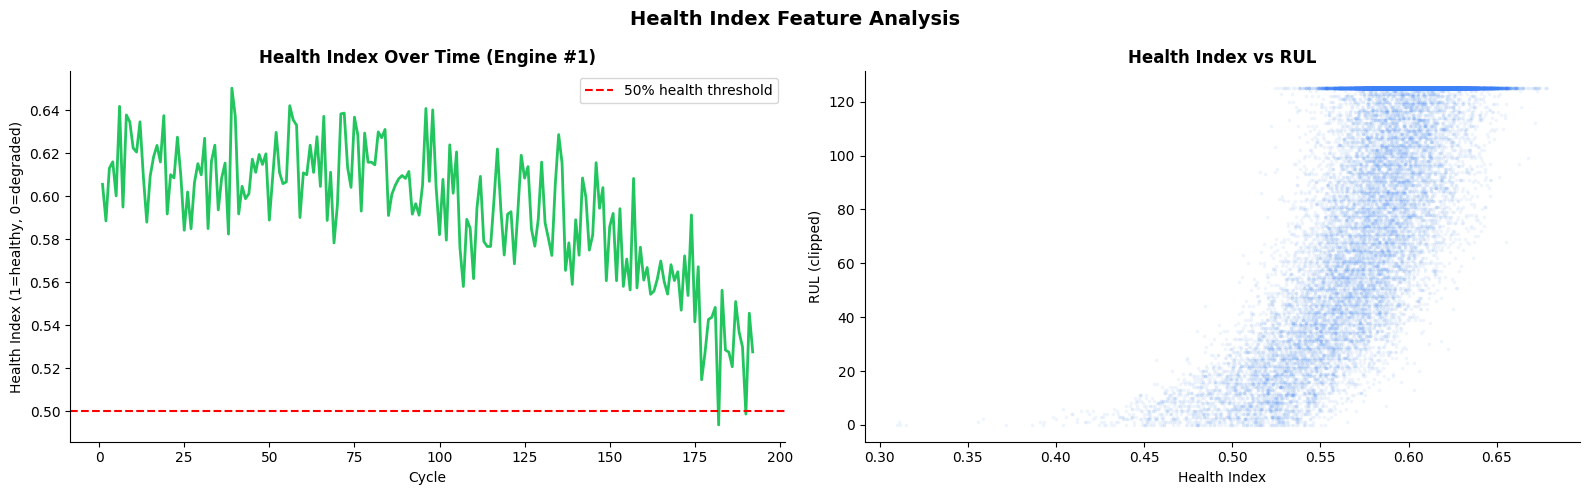

In [4]:
#  Health Index and Composite Features
print("HEALTH INDEX AND COMPOSITE FEATURES")
print()

def add_health_features(df, useful_sensors):
    df = df.copy()
    df["cycle_normalized"] = df.groupby("unit_id")["cycle"].transform(
        lambda x: x / x.max()
    )
    sensor_vals = df[useful_sensors]
    sensor_min = sensor_vals.min()
    sensor_max = sensor_vals.max()
    sensor_range = sensor_max - sensor_min + 1e-10
    normalized = (sensor_vals - sensor_min) / sensor_range
    df["health_index"] = 1 - normalized.mean(axis=1)
    df["sensor_mean"] = df[useful_sensors].mean(axis=1)
    df["sensor_std"] = df[useful_sensors].std(axis=1)
    df["sensor_max"] = df[useful_sensors].max(axis=1)
    df["sensor_min"] = df[useful_sensors].min(axis=1)
    df["sensor_range"] = df["sensor_max"] - df["sensor_min"]
    df["anomaly_score"] = df[useful_sensors].apply(
        lambda row: ((row - sensor_min) / sensor_range).max(), axis=1
    )
    df["failure_risk"] = (df["cycle_normalized"] * 0.4 + (1 - df["health_index"]) * 0.6)
    return df

train_df = add_health_features(train_df, useful_sensors)
test_df = add_health_features(test_df, useful_sensors)

composite_cols = ["health_index", "sensor_mean", "sensor_std", "sensor_max", "sensor_range", "anomaly_score", "failure_risk", "cycle_normalized"]
print("Composite features created:")
for col in composite_cols:
    corr = abs(train_df[col].corr(train_df["RUL"]))
    print(f"  {col:<20}: correlation with RUL = {corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample = train_df[train_df["unit_id"] == 1]
axes[0].plot(sample["cycle"], sample["health_index"], color="#22c55e", linewidth=2)
axes[0].set_title("Health Index Over Time (Engine #1)", fontweight="bold")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Health Index (1=healthy, 0=degraded)")
axes[0].axhline(0.5, color="red", linestyle="--", label="50% health threshold")
axes[0].legend()

axes[1].scatter(train_df["health_index"], train_df["RUL_clipped"],
                alpha=0.05, color="#3b82f6", s=3)
axes[1].set_title("Health Index vs RUL", fontweight="bold")
axes[1].set_xlabel("Health Index")
axes[1].set_ylabel("RUL (clipped)")

plt.suptitle("Health Index Feature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/health_index.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Add Failure Classification Target and Feature Importance
from sklearn.ensemble import RandomForestRegressor

print("FAILURE CLASSIFICATION TARGETS")
print()

ALERT_THRESHOLDS = [15, 30, 50]
for t in ALERT_THRESHOLDS:
    train_df[f"failure_within_{t}"] = (train_df["RUL"] <= t).astype(int)
    rate = train_df[f"failure_within_{t}"].mean() * 100
    print(f"  failure_within_{t:2d}: {train_df[f'failure_within_{t}'].sum():,} samples ({rate:.1f}% positive)")

print()
print("FEATURE IMPORTANCE RANKING")
print()

drop_cols = ["unit_id", "cycle", "op1", "op2", "op3", "RUL", "RUL_clipped",
             "life_pct", "life_stage"] + [f"failure_within_{t}" for t in ALERT_THRESHOLDS]
drop_cols += [c for c in train_df.columns if c in ["s1","s5","s6","s10","s16","s18","s19"]]

feature_cols = [c for c in train_df.columns if c not in drop_cols]
feature_cols = [c for c in feature_cols if train_df[c].dtype in ["float64","int64","float32","int32"]]

X = train_df[feature_cols].fillna(0)
y = train_df["RUL_clipped"]

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=8)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 15 features:")
for i, (feat, imp) in enumerate(importances.head(15).items(), 1):
    tag = "ENGINEERED" if any(x in feat for x in ["roll_","lag_","diff_","health","sensor_","anomaly","failure_risk","cycle_norm"]) else "original"
    print(f"  {i:2}. {feat:<35} {imp:.6f}  [{tag}]")

eng_imp = importances[[f for f in importances.index if any(x in f for x in ["roll_","lag_","diff_","health","sensor_","anomaly","failure_risk","cycle_norm"])]].sum()
orig_imp = importances[[f for f in importances.index if f not in [x for x in importances.index if any(y in x for y in ["roll_","lag_","diff_","health","sensor_","anomaly","failure_risk","cycle_norm"])]]].sum()
print()
print(f"Engineered features importance: {eng_imp/(eng_imp+orig_imp)*100:.1f}%")
print(f"Original features importance  : {orig_imp/(eng_imp+orig_imp)*100:.1f}%")

FAILURE CLASSIFICATION TARGETS

  failure_within_15: 1,600 samples (7.8% positive)
  failure_within_30: 3,100 samples (15.0% positive)
  failure_within_50: 5,100 samples (24.7% positive)

FEATURE IMPORTANCE RANKING

Top 15 features:
   1. cycle_normalized                    0.596420  [ENGINEERED]
   2. failure_risk                        0.366757  [ENGINEERED]
   3. s21_roll_min_30                     0.001970  [ENGINEERED]
   4. s4_roll_max_30                      0.001945  [ENGINEERED]
   5. s11_roll_max_30                     0.001632  [ENGINEERED]
   6. s21_roll_max_30                     0.001421  [ENGINEERED]
   7. s7_roll_min_30                      0.001133  [ENGINEERED]
   8. s12_roll_max_30                     0.001093  [ENGINEERED]
   9. s4_roll_min_30                      0.001068  [ENGINEERED]
  10. s15_roll_max_30                     0.000934  [ENGINEERED]
  11. sensor_std                          0.000904  [ENGINEERED]
  12. s7_roll_max_30                      0.000864  

In [7]:
# Save Engineered Dataset
print("SAVING ENGINEERED DATASETS")
print()

drop_for_save = ["life_pct", "life_stage", "op3"]
train_save = train_df.drop(columns=[c for c in drop_for_save if c in train_df.columns])
train_save = train_save.fillna(0)

test_save = test_df.copy()
test_max_cycles = test_df.groupby("unit_id")["cycle"].max().reset_index()
test_max_cycles.columns = ["unit_id", "last_cycle"]
test_save = test_save.merge(test_max_cycles, on="unit_id")
test_save = test_save[test_save["cycle"] == test_save["last_cycle"]].copy()
test_save = test_save.drop(columns=["last_cycle"])
test_save["RUL_true"] = rul_df["RUL"].values
test_save = test_save.fillna(0)

train_save.to_csv("../../data/equipment_failure/train_engineered.csv", index=False)
test_save.to_csv("../../data/equipment_failure/test_engineered.csv", index=False)

feature_cols_final = [c for c in feature_cols if c in train_save.columns]
import json
meta["feature_cols"] = feature_cols_final
meta["alert_thresholds"] = ALERT_THRESHOLDS
with open("../../data/equipment_failure/meta.json", "w") as f:
    json.dump(meta, f, indent=4)

print(f"Train engineered : {train_save.shape}")
print(f"Test engineered  : {test_save.shape} (last cycle per engine)")
print(f"Total features   : {len(feature_cols_final)}")
print()


SAVING ENGINEERED DATASETS

Train engineered : (20631, 171)
Test engineered  : (100, 168) (last cycle per engine)
Total features   : 155

